# Industry Signal Intelligence Notebook — All API Sources, Safe Website Handling

This notebook pulls signals from every API-style fetcher supported by `Woys/text-ingest` and analyzes how those signals may affect a target industry. Optional website/RSS/HTML crawlers are kept behind switches because they are not APIs and can fail or hang on slow pages.

Use it to monitor:

- policy and regulatory changes
- inventions and technical shifts
- market and competitive movement
- industry challenges and headwinds
- customer/adoption and operating-risk signals


## 0. Install / setup

Run this notebook from inside the cloned `Woys/text-ingest` repository root, or from a subfolder such as `examples/`.

This notebook is configured to use **all fetcher/API sources supported by the current repo**. If Jupyter accidentally imports an old `data_ingestion` package from `site-packages`, the next setup cell forces Python to import the local repo's `src/data_ingestion` instead.

Optional environment variables:

- `NEWSAPI_KEY` for NewsAPI
- `GUARDIAN_API_KEY` for Guardian; the repo can also use Guardian's default/test behavior when available
- `GITHUB_TOKEN` for higher GitHub API limits



In [6]:
# Run this notebook from the cloned repo, or uncomment the commands below.
# !git clone https://github.com/Woys/text-ingest.git
# %cd text-ingest

# Run once in a fresh environment.
# %pip install -e ".[dev]"
# %pip install pandas numpy matplotlib scikit-learn python-dateutil tqdm



### Force Jupyter to use the local repo version

This prevents the common bug where your notebook imports an older installed `data_ingestion` package from `site-packages`, causing newer API sources such as `edgar`, `github`, `googlenews`, `guardian`, `reddit`, `website`, and `website_html` to be skipped.



In [7]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def find_text_ingest_repo_root(start: Path) -> Path | None:
    """Find a local Woys/text-ingest checkout containing src/data_ingestion."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src" / "data_ingestion").exists() and (
            candidate / "pyproject.toml"
        ).exists():
            return candidate
    return None


REPO_ROOT = find_text_ingest_repo_root(Path.cwd())

if REPO_ROOT is None:
    raise RuntimeError(
        "Could not find the local text-ingest repo. Run this notebook from the repo root "
        "or from a subfolder such as examples/. If needed: git clone https://github.com/Woys/text-ingest.git"
    )

SRC_PATH = str(REPO_ROOT / "src")

# Put local src first so imports prefer the current repo over any old pip-installed copy.
if SRC_PATH in sys.path:
    sys.path.remove(SRC_PATH)
sys.path.insert(0, SRC_PATH)

# If a stale package was already imported in this kernel, unload it.
for module_name in list(sys.modules):
    if module_name == "data_ingestion" or module_name.startswith("data_ingestion."):
        del sys.modules[module_name]

import data_ingestion

print("Repo root:", REPO_ROOT)
print("Using data_ingestion from:", Path(data_ingestion.__file__).resolve())
print("Expected local src path:", SRC_PATH)

Repo root: /home/daniilmiheev/p/de/textDump/data_ingestion
Using data_ingestion from: /home/daniilmiheev/p/de/textDump/data_ingestion/src/data_ingestion/__init__.py
Expected local src path: /home/daniilmiheev/p/de/textDump/data_ingestion/src


## 1. Configure the industry and time window

In [8]:
from __future__ import annotations

import json
import math
import re
from collections import defaultdict
from datetime import date, datetime, timedelta
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# CHANGE THIS SECTION FOR YOUR TARGET INDUSTRY
# -----------------------------------------------------------------------------
INDUSTRY = "agriculture chemicals"  # examples: "marketing agency", "hospitality AI", "cybersecurity", "EV batteries"

INDUSTRY_DESCRIPTION = (
    "Companies that sell crop inputs, fertilizers, pesticides, soil technology, "
    "agricultural chemicals, precision agriculture software, and adjacent services."
)

# Core terms decide relevance. Use nouns your target users, regulators, and competitors would use.
INDUSTRY_TERMS = [
    "agriculture",
    "agricultural chemicals",
    "crop protection",
    "fertilizer",
    "pesticide",
    "herbicide",
    "fungicide",
    "soil health",
    "precision agriculture",
]

# Adjacent terms catch weak signals that may become important.
ADJACENT_TERMS = [
    "supply chain",
    "tariff",
    "subsidy",
    "epa",
    "regulation",
    "climate",
    "water quality",
    "biotech",
    "sensor",
    "robotics",
    "ai",
]

# Challenge terms are broader than risk terms. They represent industry headwinds
# that may reduce growth, margins, adoption, or operational resilience.
CHALLENGE_TERMS = [
    "challenge",
    "headwind",
    "barrier",
    "constraint",
    "bottleneck",
    "cost pressure",
    "margin pressure",
    "labor shortage",
    "talent shortage",
    "supply disruption",
    "regulatory burden",
    "compliance cost",
    "customer adoption",
    "pricing pressure",
    "competition",
    "substitution",
    "lawsuit",
    "enforcement",
    "ban",
    "shortage",
    "volatility",
    "uncertainty",
]

# A shorter date window is better for daily monitoring; a longer window is better for trend discovery.
END_DATE = date.today().isoformat()
START_DATE = (date.today() - timedelta(days=90)).isoformat()

# Keep this low while testing. Increase once your API keys/rate limits are stable.
MAX_PAGES = 1

# -----------------------------------------------------------------------------
# API/source execution controls
# -----------------------------------------------------------------------------
# The notebook now runs all actual API fetcher types by default.
# The repo also has website/HTML fetchers. Those are useful, but they are not APIs
# and can hang on slow sites or fail when a page has no RSS/Atom feed. Your logs
# showed exactly this with EPA RSS autodiscovery and USDA timeouts, so these are
# opt-in instead of blocking the all-API run.
INCLUDE_OPTIONAL_WEBSITE_SOURCES = False
INCLUDE_WEBSITE_RSS_AUTODISCOVERY = (
    False  # safer default: RSS autodiscovery often fails on normal pages
)
INCLUDE_WEBSITE_HTML_FALLBACK = False  # turn on when you want official-site crawling
ENABLE_WEBSITE_PREFLIGHT = (
    True  # quick skip for slow/unreachable websites when website sources are enabled
)
WEBSITE_PREFLIGHT_TIMEOUT_SECONDS = 8
WEBSITE_MAX_ITEMS = 10
WEBSITE_MAX_CANDIDATE_LINKS = 25

OUT_DIR = Path("data/industry_signal_intelligence")
OUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_JSONL = OUT_DIR / "raw_industry_signals.jsonl"
CLEAN_CSV = OUT_DIR / "clean_industry_signals.csv"
TOP_SIGNALS_CSV = OUT_DIR / "top_business_impact_signals.csv"
REPORT_MD = OUT_DIR / "industry_signal_report.md"
API_COVERAGE_CSV = OUT_DIR / "api_fetcher_coverage.csv"

print(
    {
        "industry": INDUSTRY,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "output_dir": str(OUT_DIR),
        "max_pages": MAX_PAGES,
        "include_optional_website_sources": INCLUDE_OPTIONAL_WEBSITE_SOURCES,
    }
)

{'industry': 'agriculture chemicals', 'start_date': '2026-02-01', 'end_date': '2026-05-02', 'output_dir': 'data/industry_signal_intelligence', 'max_pages': 1, 'include_optional_website_sources': False}


## 2. Build cross-source API specs

This cell prepares specs for every API-like source. `website` and `website_html` are available too, but they are optional because they crawl pages rather than query stable APIs.


In [9]:
def q(*parts: str) -> str:
    return " ".join(p.strip() for p in parts if p and p.strip())


# Every source currently documented in Woys/text-ingest.
# "website" and "website_html" are source fetchers, but they are not API endpoints;
# they crawl/parse web pages and can be slow or flaky. Actual API-like sources run by default.
ALL_REPO_FETCHER_SOURCES = [
    "openalex",
    "crossref",
    "newsapi",
    "hackernews",
    "federalregister",
    "website",
    "website_html",
    "wikipedia",
    "reddit",
    "edgar",
    "github",
    "stackexchange",
    "openlibrary",
    "googlenews",
    "guardian",
]

NON_API_WEBSITE_SOURCES = {"website", "website_html"}
ALL_API_FETCHER_SOURCES = [
    s for s in ALL_REPO_FETCHER_SOURCES if s not in NON_API_WEBSITE_SOURCES
]

QUERY_LENSES = {
    "general": q(INDUSTRY, "business market policy technology"),
    "policy_regulation": q(
        INDUSTRY, "regulation policy rule law enforcement guidance compliance"
    ),
    "invention_technology": q(
        INDUSTRY, "patent invention technology startup breakthrough research"
    ),
    "market_competition": q(
        INDUSTRY, "investment merger acquisition pricing shortage demand competitor"
    ),
    "industry_challenges": q(
        INDUSTRY,
        "challenge headwind barrier constraint bottleneck adoption cost margin labor supply chain disruption",
    ),
    "risk": q(
        INDUSTRY, "ban lawsuit recall shortage tariff disruption fine enforcement"
    ),
    "customer_demand": q(
        INDUSTRY, "customer demand adoption procurement budget churn willingness to pay"
    ),
    "operations": q(
        INDUSTRY,
        "operations supply chain logistics capacity hiring talent implementation",
    ),
}


def drop_none(config: dict[str, Any]) -> dict[str, Any]:
    """Remove None values so optional keys do not break strict Pydantic configs."""
    return {k: v for k, v in config.items() if v is not None}


def query_config(query: str, **overrides: Any) -> dict[str, Any]:
    """Common config for query-based API fetchers."""
    return drop_none(
        {
            "query": query,
            "max_pages": MAX_PAGES,
            "start_date": START_DATE,
            "end_date": END_DATE,
            "languages": ["en"],
            **overrides,
        }
    )


def website_config(site_url: str, **overrides: Any) -> dict[str, Any]:
    """Config for RSS/Atom/autodiscovery websites. Disabled by default."""
    return drop_none(
        {
            "site_url": site_url,
            "query": INDUSTRY,
            "max_items": WEBSITE_MAX_ITEMS,
            "start_date": START_DATE,
            "end_date": END_DATE,
            "languages": ["en"],
            **overrides,
        }
    )


def website_html_config(site_url: str, **overrides: Any) -> dict[str, Any]:
    """Config for non-RSS HTML websites. Disabled by default."""
    return drop_none(
        {
            "site_url": site_url,
            "query": INDUSTRY,
            "max_items": WEBSITE_MAX_ITEMS,
            "max_candidate_links": WEBSITE_MAX_CANDIDATE_LINKS,
            "include_list_pages_as_items": True,
            "start_date": START_DATE,
            "end_date": END_DATE,
            "languages": ["en"],
            **overrides,
        }
    )


FETCHER_SPECS: list[dict[str, Any]] = []
FETCHER_SPEC_ROWS: list[dict[str, Any]] = []


def add_fetcher(
    source: str, config: dict[str, Any], lens: str, purpose: str, enabled: bool = True
) -> None:
    """Add a FetcherSpec plus a human-readable row used for coverage reporting."""
    row = {
        "idx": len(FETCHER_SPEC_ROWS) + 1,
        "source": source,
        "source_class": "website" if source in NON_API_WEBSITE_SOURCES else "api",
        "enabled": bool(enabled),
        "lens": lens,
        "purpose": purpose,
        "query": config.get("query", ""),
        "site_url": config.get("site_url", ""),
    }
    FETCHER_SPEC_ROWS.append(row)
    if enabled:
        FETCHER_SPECS.append(
            {"source": source, "config": config, "_row_idx": row["idx"]}
        )


# -------------------------------------------------------------------------
# Research / invention / academic weak-signal APIs
# -------------------------------------------------------------------------
add_fetcher(
    "openalex",
    query_config(QUERY_LENSES["invention_technology"], per_page=50),
    "invention_technology",
    "research papers, technical shifts, early invention signals",
)
add_fetcher(
    "crossref",
    query_config(QUERY_LENSES["invention_technology"], rows=50),
    "invention_technology",
    "scholarly metadata, research trends, academic publications",
)
add_fetcher(
    "openlibrary",
    query_config(q(INDUSTRY, "business technology policy market"), page_size=25),
    "general",
    "books/reports as slower but useful market-context signals",
)


# -------------------------------------------------------------------------
# Policy / regulation / enforcement APIs
# -------------------------------------------------------------------------
add_fetcher(
    "federalregister",
    query_config(QUERY_LENSES["policy_regulation"], per_page=50),
    "policy_regulation",
    "proposed/final rules, guidance, agency documents",
)
add_fetcher(
    "federalregister",
    query_config(QUERY_LENSES["industry_challenges"], per_page=50),
    "industry_challenges",
    "policy-linked operational and compliance headwinds",
)


# -------------------------------------------------------------------------
# Public-company filings / competitor APIs
# -------------------------------------------------------------------------
add_fetcher(
    "edgar",
    query_config(QUERY_LENSES["market_competition"], per_page=50),
    "market_competition",
    "SEC filings, competitor risk factors, public-company disclosures",
)
add_fetcher(
    "edgar",
    query_config(QUERY_LENSES["risk"], per_page=50),
    "risk",
    "public-company risks, litigation, shortages, tariff/disruption signals",
)


# -------------------------------------------------------------------------
# News APIs
# -------------------------------------------------------------------------
add_fetcher(
    "googlenews",
    query_config(
        QUERY_LENSES["general"], page_size=50, hl="en-US", gl="US", ceid="US:en"
    ),
    "general",
    "broad current news without requiring a paid API key",
)
add_fetcher(
    "googlenews",
    query_config(
        QUERY_LENSES["industry_challenges"],
        page_size=50,
        hl="en-US",
        gl="US",
        ceid="US:en",
    ),
    "industry_challenges",
    "news about headwinds and industry pressure",
)

add_fetcher(
    "guardian",
    query_config(
        QUERY_LENSES["general"], api_key=os.getenv("GUARDIAN_API_KEY"), page_size=25
    ),
    "general",
    "Guardian Content API articles and market/policy coverage",
)
add_fetcher(
    "guardian",
    query_config(
        QUERY_LENSES["industry_challenges"],
        api_key=os.getenv("GUARDIAN_API_KEY"),
        page_size=25,
    ),
    "industry_challenges",
    "Guardian articles about headwinds and risks",
)

# Always include NewsAPI so the coverage table shows it.
# The build cell will skip cleanly if NEWSAPI_KEY is absent.
add_fetcher(
    "newsapi",
    query_config(
        QUERY_LENSES["general"],
        api_key=os.getenv("NEWSAPI_KEY"),
        page_size=50,
        language="en",
    ),
    "general",
    "NewsAPI everything endpoint; requires NEWSAPI_KEY",
)
add_fetcher(
    "newsapi",
    query_config(
        QUERY_LENSES["industry_challenges"],
        api_key=os.getenv("NEWSAPI_KEY"),
        page_size=50,
        language="en",
    ),
    "industry_challenges",
    "NewsAPI challenge/headwind coverage; requires NEWSAPI_KEY",
)


# -------------------------------------------------------------------------
# Developer, technical, and community APIs
# -------------------------------------------------------------------------
add_fetcher(
    "github",
    query_config(
        QUERY_LENSES["invention_technology"],
        per_page=25,
        sort="updated",
        github_token=os.getenv("GITHUB_TOKEN"),
    ),
    "invention_technology",
    "open-source tools, developer adoption, emerging technical wedges",
)
add_fetcher(
    "hackernews",
    query_config(
        QUERY_LENSES["invention_technology"], hits_per_page=50, use_date_sort=True
    ),
    "invention_technology",
    "technical community discussion and early startup/tool signals",
)
add_fetcher(
    "hackernews",
    query_config(
        QUERY_LENSES["market_competition"], hits_per_page=50, use_date_sort=True
    ),
    "market_competition",
    "startup/competitive discussion from technical communities",
)
add_fetcher(
    "reddit",
    query_config(QUERY_LENSES["risk"], page_size=25, sort="new"),
    "risk",
    "front-line complaints, adoption barriers, buyer/user pain",
)
add_fetcher(
    "reddit",
    query_config(QUERY_LENSES["customer_demand"], page_size=25, sort="new"),
    "customer_demand",
    "customer demand, churn, and buying-friction weak signals",
)
add_fetcher(
    "stackexchange",
    query_config(
        QUERY_LENSES["invention_technology"],
        page_size=25,
        site="stackoverflow",
        sort="activity",
    ),
    "invention_technology",
    "technical implementation pain and tooling questions",
)
add_fetcher(
    "wikipedia",
    query_config(INDUSTRY, page_size=10, wiki_language="en"),
    "general",
    "baseline industry/entity context",
)


# -------------------------------------------------------------------------
# Optional website/RSS/HTML sources. These are NOT APIs; keep off for a clean all-API run.
# -------------------------------------------------------------------------
WATCH_SITES = [
    {"name": "EPA news releases", "site_url": "https://www.epa.gov/newsreleases"},
    {"name": "USDA news", "site_url": "https://www.usda.gov/media/press-releases"},
    {
        "name": "FDA news",
        "site_url": "https://www.fda.gov/news-events/fda-newsroom/press-announcements",
    },
]

for site in WATCH_SITES:
    add_fetcher(
        "website",
        website_config(site["site_url"]),
        "watched_site_rss",
        f"OPTIONAL non-API RSS/Atom/autodiscovery watch: {site['name']}",
        enabled=INCLUDE_OPTIONAL_WEBSITE_SOURCES and INCLUDE_WEBSITE_RSS_AUTODISCOVERY,
    )
    add_fetcher(
        "website_html",
        website_html_config(
            site["site_url"],
            list_page_urls=[site["site_url"]],
            link_include_patterns=[
                "news",
                "press",
                "release",
                "blog",
                "article",
                "update",
                "rule",
                "regulation",
            ],
            link_exclude_patterns=[
                "privacy",
                "contact",
                "subscribe",
                "events/calendar",
                "email-subscriptions",
            ],
        ),
        "watched_site_html",
        f"OPTIONAL non-API HTML fallback watch: {site['name']}",
        enabled=INCLUDE_OPTIONAL_WEBSITE_SOURCES and INCLUDE_WEBSITE_HTML_FALLBACK,
    )


# Validate that the notebook has an enabled spec for every actual API source.
# Optional website sources are validated separately only if enabled.
enabled_sources = {spec["source"] for spec in FETCHER_SPECS}
missing_api_specs = sorted(set(ALL_API_FETCHER_SOURCES) - enabled_sources)
if missing_api_specs:
    raise AssertionError(f"Missing enabled API fetcher specs for: {missing_api_specs}")

if INCLUDE_OPTIONAL_WEBSITE_SOURCES:
    expected_website_sources = set()
    if INCLUDE_WEBSITE_RSS_AUTODISCOVERY:
        expected_website_sources.add("website")
    if INCLUDE_WEBSITE_HTML_FALLBACK:
        expected_website_sources.add("website_html")
    missing_website_specs = sorted(expected_website_sources - enabled_sources)
    if missing_website_specs:
        raise AssertionError(
            f"Missing enabled website fetcher specs for: {missing_website_specs}"
        )

fetcher_spec_df = pd.DataFrame(FETCHER_SPEC_ROWS)
display(fetcher_spec_df)

print(
    f"Prepared {len(FETCHER_SPECS)} enabled fetcher specs across {pd.Series([s['source'] for s in FETCHER_SPECS]).nunique()} unique enabled source types."
)
print(
    "Enabled API sources:",
    ", ".join(sorted(set(ALL_API_FETCHER_SOURCES) & enabled_sources)),
)
print(
    "Optional website sources enabled:",
    ", ".join(sorted(set(NON_API_WEBSITE_SOURCES) & enabled_sources)) or "none",
)

,idx,source,source_class,enabled,lens,purpose,query,site_url
0,1,openalex,api,True,invention_technology,"research papers, technical shifts, early inven...",agriculture chemicals patent invention technol...,
1,2,crossref,api,True,invention_technology,"scholarly metadata, research trends, academic ...",agriculture chemicals patent invention technol...,
2,3,openlibrary,api,True,general,books/reports as slower but useful market-cont...,agriculture chemicals business technology poli...,
3,4,federalregister,api,True,policy_regulation,"proposed/final rules, guidance, agency documents",agriculture chemicals regulation policy rule l...,
4,5,federalregister,api,True,industry_challenges,policy-linked operational and compliance headw...,agriculture chemicals challenge headwind barri...,
5,6,edgar,api,True,market_competition,"SEC filings, competitor risk factors, public-c...",agriculture chemicals investment merger acquis...,
6,7,edgar,api,True,risk,"public-company risks, litigation, shortages, t...",agriculture chemicals ban lawsuit recall short...,
7,8,googlenews,api,True,general,broad current news without requiring a paid AP...,agriculture chemicals business market policy t...,
8,9,googlenews,api,True,industry_challenges,news about headwinds and industry pressure,agriculture chemicals challenge headwind barri...,
9,10,guardian,api,True,general,Guardian Content API articles and market/polic...,agriculture chemicals business market policy t...,


Prepared 20 enabled fetcher specs across 13 unique enabled source types.
Enabled API sources: crossref, edgar, federalregister, github, googlenews, guardian, hackernews, newsapi, openalex, openlibrary, reddit, stackexchange, wikipedia
Optional website sources enabled: none


### Version note

This notebook now prepares specs for **every fetcher source documented in the current repo**:

`openalex`, `crossref`, `newsapi`, `hackernews`, `federalregister`, `website`, `website_html`, `wikipedia`, `reddit`, `edgar`, `github`, `stackexchange`, `openlibrary`, `googlenews`, and `guardian`.

The setup cell above forces Jupyter to import `src/data_ingestion` from your local repo instead of an older `site-packages` install. If any source still appears as unsupported, update the repo and reinstall from the repo root:

```bash
git pull
pip install -e ".[dev]"
```

Sources that require keys, especially `newsapi`, will still be skipped until the required environment variables are set.



## 3. Run ingestion with `text-ingest`

The run cell builds each source independently, writes a coverage table, and continues when a source is unsupported, missing a key, rate-limited, or unavailable.


In [10]:
from typing import Literal, get_args, get_origin

from data_ingestion.config import (
    FetcherSpec,
    JsonlSinkConfig,
    PipelineConfig,
    RuntimeOptimizationConfig,
)
from data_ingestion.factories import build_fetcher
from data_ingestion.pipeline import DataDumperPipeline
from data_ingestion.sinks.jsonl import JsonlSink


def allowed_fetcher_sources() -> set[str] | None:
    """Return sources allowed by the imported package's FetcherSpec."""
    try:
        annotation = FetcherSpec.model_fields["source"].annotation
        if get_origin(annotation) is Literal:
            return set(str(x) for x in get_args(annotation))
    except Exception:
        return None
    return None


def preflight_website_url(url: str) -> tuple[bool, str]:
    """Fast preflight for optional website sources so slow pages do not stall the notebook."""
    if not ENABLE_WEBSITE_PREFLIGHT or not url:
        return True, ""
    try:
        import requests

        response = requests.get(
            url,
            timeout=WEBSITE_PREFLIGHT_TIMEOUT_SECONDS,
            headers={
                "User-Agent": "text-ingest-notebook/1.0 (+https://github.com/Woys/text-ingest)"
            },
        )
        if response.status_code >= 400:
            return False, f"website preflight HTTP {response.status_code}"
        return True, ""
    except Exception as exc:
        return False, f"website preflight failed: {type(exc).__name__}: {exc}"


available_sources = allowed_fetcher_sources()

print("Expected API sources:")
print(", ".join(ALL_API_FETCHER_SOURCES))
print("\nOptional non-API website sources:")
print(", ".join(sorted(NON_API_WEBSITE_SOURCES)))

if available_sources:
    print("\nFetcher sources allowed by imported package:")
    print(", ".join(sorted(available_sources)))

    missing_api_in_imported_package = sorted(
        set(ALL_API_FETCHER_SOURCES) - set(available_sources)
    )
    if missing_api_in_imported_package:
        print(
            "\nWARNING: These expected API sources are not available in the imported package:"
        )
        print(", ".join(missing_api_in_imported_package))
        print(
            "Check the 'Using data_ingestion from:' path in the setup cell. It should point to the local repo src/ folder."
        )
else:
    print("\nCould not introspect allowed sources; will try each source individually.")


# Build fetchers one by one so one unsupported source/API-key/config issue
# does not kill the notebook. Website sources get a quick preflight if enabled.
built_fetchers = []
build_rows = []
row_lookup = {row["idx"]: row for row in FETCHER_SPEC_ROWS}

for build_idx, spec in enumerate(FETCHER_SPECS, start=1):
    source = spec.get("source")
    row_idx = spec.get("_row_idx", build_idx)
    spec_row = row_lookup.get(row_idx, {})
    clean_spec = {"source": spec.get("source"), "config": spec.get("config", {})}
    config = clean_spec.get("config", {})
    query_or_site = config.get("query") or config.get("site_url", "")
    source_class = "website" if source in NON_API_WEBSITE_SOURCES else "api"

    if available_sources is not None and source not in available_sources:
        build_rows.append(
            {
                "idx": row_idx,
                "source": source,
                "source_class": source_class,
                "status": "skipped",
                "reason": "not supported by imported package; update repo and reinstall with pip install -e '.[dev]'",
                "lens": spec_row.get("lens", ""),
                "purpose": spec_row.get("purpose", ""),
                "query_or_site": query_or_site,
            }
        )
        continue

    if source in NON_API_WEBSITE_SOURCES:
        ok, reason = preflight_website_url(config.get("site_url", ""))
        if not ok:
            build_rows.append(
                {
                    "idx": row_idx,
                    "source": source,
                    "source_class": source_class,
                    "status": "skipped",
                    "reason": reason,
                    "lens": spec_row.get("lens", ""),
                    "purpose": spec_row.get("purpose", ""),
                    "query_or_site": query_or_site,
                }
            )
            continue

    try:
        fetcher = build_fetcher(clean_spec)
        built_fetchers.append(fetcher)
        build_rows.append(
            {
                "idx": row_idx,
                "source": source,
                "source_class": source_class,
                "status": "built",
                "reason": "",
                "lens": spec_row.get("lens", ""),
                "purpose": spec_row.get("purpose", ""),
                "query_or_site": query_or_site,
            }
        )
    except Exception as exc:
        build_rows.append(
            {
                "idx": row_idx,
                "source": source,
                "source_class": source_class,
                "status": "skipped",
                "reason": f"{type(exc).__name__}: {exc}",
                "lens": spec_row.get("lens", ""),
                "purpose": spec_row.get("purpose", ""),
                "query_or_site": query_or_site,
            }
        )


api_fetcher_coverage = pd.DataFrame(build_rows)

source_coverage = (
    api_fetcher_coverage.groupby(["source_class", "source"])
    .agg(
        specs=("idx", "count"),
        built=("status", lambda s: int((s == "built").sum())),
        skipped=("status", lambda s: int((s == "skipped").sum())),
        last_reason=("reason", lambda s: next((x for x in s if x), "")),
    )
    .reset_index()
    .sort_values(["source_class", "built", "source"], ascending=[True, False, True])
)

api_fetcher_coverage.to_csv(API_COVERAGE_CSV, index=False)

built_api_sources = set(
    api_fetcher_coverage.loc[
        (api_fetcher_coverage["source_class"] == "api")
        & (api_fetcher_coverage["status"] == "built"),
        "source",
    ]
)
missing_built_api_sources = sorted(set(ALL_API_FETCHER_SOURCES) - built_api_sources)

print(
    f"\nBuilt {len(built_fetchers)} fetcher instance(s) from {len(FETCHER_SPECS)} enabled prepared specs."
)
print(
    f"Built API source types: {len(built_api_sources)}/{len(ALL_API_FETCHER_SOURCES)}"
)
print(f"Coverage file: {API_COVERAGE_CSV}")

if missing_built_api_sources:
    print("\nAPI source types not built in this run:")
    print(", ".join(missing_built_api_sources))
    print(
        "Usually this means a missing API key, unsupported local package, or strict config validation. Check the coverage table reasons."
    )

display(source_coverage)
display(api_fetcher_coverage)

if not built_fetchers:
    raise RuntimeError(
        "No fetchers were built. Most likely the notebook is importing an old data_ingestion package "
        "or required API keys/config are missing. Confirm the setup cell prints a local repo path like "
        '.../text-ingest/src/data_ingestion/__init__.py, then run `pip install -e ".[dev]"` from the repo root.'
    )


# fail_fast=False lets the pipeline continue if one source fails or rate-limits.
# write_raw_payload=False keeps the output smaller and safer for downstream analysis.
pipeline_config = PipelineConfig(
    fail_fast=False,
    runtime=RuntimeOptimizationConfig(
        enrich_full_text=False,
        write_raw_payload=False,
        drop_raw_payload_after_transform=True,
        sink_write_batch_size=500,
    ),
)

sink = JsonlSink(JsonlSinkConfig(output_file=str(RAW_JSONL), append=False))
pipeline = DataDumperPipeline(sink=sink, config=pipeline_config)
summary = pipeline.run(built_fetchers)

summary_dict = summary.model_dump() if hasattr(summary, "model_dump") else dict(summary)
summary_dict

2026-05-02 18:36:29,985 | INFO     | data_ingestion.factories | Built fetcher source=openalex class=OpenAlexFetcher
2026-05-02 18:36:29,987 | INFO     | data_ingestion.factories | Built fetcher source=crossref class=CrossRefFetcher
2026-05-02 18:36:29,989 | INFO     | data_ingestion.factories | Built fetcher source=openlibrary class=OpenLibraryFetcher
2026-05-02 18:36:29,990 | INFO     | data_ingestion.factories | Built fetcher source=federalregister class=FederalRegisterFetcher
2026-05-02 18:36:29,993 | INFO     | data_ingestion.factories | Built fetcher source=federalregister class=FederalRegisterFetcher
2026-05-02 18:36:29,995 | INFO     | data_ingestion.factories | Built fetcher source=edgar class=EdgarFetcher
2026-05-02 18:36:29,997 | INFO     | data_ingestion.factories | Built fetcher source=edgar class=EdgarFetcher
2026-05-02 18:36:30,000 | INFO     | data_ingestion.factories | Built fetcher source=googlenews class=GoogleNewsFetcher
2026-05-02 18:36:30,001 | INFO     | data_inge

Expected API sources:
openalex, crossref, newsapi, hackernews, federalregister, wikipedia, reddit, edgar, github, stackexchange, openlibrary, googlenews, guardian

Optional non-API website sources:
website, website_html

Fetcher sources allowed by imported package:
crossref, edgar, federalregister, github, googlenews, guardian, hackernews, newsapi, openalex, openlibrary, reddit, stackexchange, website, website_html, wikipedia

Built 18 fetcher instance(s) from 20 enabled prepared specs.
Built API source types: 12/13
Coverage file: data/industry_signal_intelligence/api_fetcher_coverage.csv

API source types not built in this run:
newsapi
Usually this means a missing API key, unsupported local package, or strict config validation. Check the coverage table reasons.


,source_class,source,specs,built,skipped,last_reason
1,api,edgar,2,2,0,
2,api,federalregister,2,2,0,
4,api,googlenews,2,2,0,
5,api,guardian,2,2,0,
6,api,hackernews,2,2,0,
10,api,reddit,2,2,0,
0,api,crossref,1,1,0,
3,api,github,1,1,0,
8,api,openalex,1,1,0,
9,api,openlibrary,1,1,0,


,idx,source,source_class,status,reason,lens,purpose,query_or_site
0,1,openalex,api,built,,invention_technology,"research papers, technical shifts, early inven...",agriculture chemicals patent invention technol...
1,2,crossref,api,built,,invention_technology,"scholarly metadata, research trends, academic ...",agriculture chemicals patent invention technol...
2,3,openlibrary,api,built,,general,books/reports as slower but useful market-cont...,agriculture chemicals business technology poli...
3,4,federalregister,api,built,,policy_regulation,"proposed/final rules, guidance, agency documents",agriculture chemicals regulation policy rule l...
4,5,federalregister,api,built,,industry_challenges,policy-linked operational and compliance headw...,agriculture chemicals challenge headwind barri...
5,6,edgar,api,built,,market_competition,"SEC filings, competitor risk factors, public-c...",agriculture chemicals investment merger acquis...
6,7,edgar,api,built,,risk,"public-company risks, litigation, shortages, t...",agriculture chemicals ban lawsuit recall short...
7,8,googlenews,api,built,,general,broad current news without requiring a paid AP...,agriculture chemicals business market policy t...
8,9,googlenews,api,built,,industry_challenges,news about headwinds and industry pressure,agriculture chemicals challenge headwind barri...
9,10,guardian,api,built,,general,Guardian Content API articles and market/polic...,agriculture chemicals business market policy t...


2026-05-02 18:36:30,080 | INFO     | data_ingestion.pipeline | Pipeline initialized fail_fast=False enrich_full_text=False sink_write_batch_size=500 transforms_enabled=False resume=False checkpoint=None
2026-05-02 18:36:30,081 | INFO     | data_ingestion.pipeline | Pipeline run started
2026-05-02 18:36:30,081 | INFO     | data_ingestion.pipeline | Starting source=openalex
2026-05-02 18:36:30,082 | INFO     | data_ingestion.fetchers.openalex | OpenAlex: requesting page=0 per_page=50 cursor=* filters=from_publication_date:2026-02-01,to_publication_date:2026-05-02
2026-05-02 18:36:30,583 | INFO     | data_ingestion.fetchers.openalex | OpenAlex: received page=0 results=3 count=3
2026-05-02 18:36:30,584 | INFO     | data_ingestion.fetchers.openalex | OpenAlex: no next cursor after pages_fetched=1
2026-05-02 18:36:30,586 | INFO     | data_ingestion.pipeline | Finished source=openalex seen=0 kept=0 dropped_by_topic=0 dropped_by_transform=0
2026-05-02 18:36:30,586 | INFO     | data_ingestion.p

{'total_records': 338,
 'by_source': {'openalex': 0,
  'crossref': 25,
  'openlibrary': 0,
  'federalregister': 23,
  'edgar': 105,
  'googlenews': 50,
  'guardian': 50,
  'github': 0,
  'hackernews': 0,
  'reddit': 50,
  'stackexchange': 25,
  'wikipedia': 10},
 'failed_sources': {},
 'by_source_stats': {'openalex': {'seen': 0,
   'kept': 0,
   'dropped_by_topic': 0,
   'dropped_by_transform': 0,
   'checkpoint_skipped': 0},
  'crossref': {'seen': 25,
   'kept': 25,
   'dropped_by_topic': 0,
   'dropped_by_transform': 0,
   'checkpoint_skipped': 0},
  'openlibrary': {'seen': 0,
   'kept': 0,
   'dropped_by_topic': 0,
   'dropped_by_transform': 0,
   'checkpoint_skipped': 0},
  'federalregister': {'seen': 0,
   'kept': 0,
   'dropped_by_topic': 0,
   'dropped_by_transform': 0,
   'checkpoint_skipped': 0},
  'edgar': {'seen': 5,
   'kept': 5,
   'dropped_by_topic': 0,
   'dropped_by_transform': 0,
   'checkpoint_skipped': 0},
  'googlenews': {'seen': 0,
   'kept': 0,
   'dropped_by_topi

## 4. Load, normalize, and deduplicate records

In [11]:
def read_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    if not path.exists():
        return pd.DataFrame()
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return pd.DataFrame(rows)


raw_df = read_jsonl(RAW_JSONL)
print(f"Raw rows: {len(raw_df):,}")
raw_df.head(3)

Raw rows: 338


,source,external_id,title,authors,published_date,url,abstract,full_text,full_text_url,topic,record_type,fetched_at,raw_payload
0,crossref,10.3390/electronics15071461,Deep Learning-Driven Atomic Norm Optimization ...,"[Ke Xu, Sining Li, Changwei Huang, Dan Wu, Cha...",2026-04-01,https://doi.org/10.3390/electronics15071461,"In this paper, we propose a downlink (DL) chan...",None,https://www.mdpi.com/2079-9292/15/7/1461/pdf,agriculture chemicals patent invention technol...,article,2026-05-02 22:36:30.927538+00:00,{}
1,crossref,10.1016/j.tibtech.2026.03.011,Scientific breakthrough versus successful star...,"[Sherry Yang, Jennifer R. Cochran, Rowan Chapm...",2026-04-01,https://doi.org/10.1016/j.tibtech.2026.03.011,None,None,https://api.elsevier.com/content/article/PII:S...,agriculture chemicals patent invention technol...,article,2026-05-02 22:36:30.927701+00:00,{}
2,crossref,10.1038/s41598-026-38452-4,Akkermansia muciniphila affects colitis by inh...,"[Lin Zhang, Yijuan Liu, Kaiyan Wei, Junxi Wang...",2026-02-16,https://doi.org/10.1038/s41598-026-38452-4,None,None,https://www.nature.com/articles/s41598-026-384...,agriculture chemicals patent invention technol...,article,2026-05-02 22:36:30.927767+00:00,{}


In [12]:
def norm_text(value: Any) -> str:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return ""
    if isinstance(value, list):
        return " ".join(norm_text(v) for v in value)
    return str(value)


def compact_spaces(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def normalize_title(title: str) -> str:
    title = title.lower()
    title = re.sub(r"[^a-z0-9]+", " ", title)
    return compact_spaces(title)


if raw_df.empty:
    raise RuntimeError(
        "No records were ingested. Check API keys, rate limits, date window, and query terms."
    )

for col in [
    "source",
    "external_id",
    "title",
    "abstract",
    "full_text",
    "url",
    "topic",
    "record_type",
    "published_date",
    "fetched_at",
]:
    if col not in raw_df.columns:
        raw_df[col] = None

raw_df["title"] = raw_df["title"].map(norm_text).map(compact_spaces)
raw_df["abstract"] = raw_df["abstract"].map(norm_text).map(compact_spaces)
raw_df["full_text"] = raw_df["full_text"].map(norm_text).map(compact_spaces)
raw_df["url"] = raw_df["url"].map(norm_text).map(compact_spaces)
raw_df["topic"] = raw_df["topic"].map(norm_text).map(compact_spaces)

raw_df["text"] = (
    raw_df["title"].fillna("")
    + "\n"
    + raw_df["abstract"].fillna("")
    + "\n"
    + raw_df["full_text"].fillna("")
    + "\n"
    + raw_df["topic"].fillna("")
).map(compact_spaces)

raw_df["published_date"] = pd.to_datetime(
    raw_df["published_date"], errors="coerce", utc=True
)
raw_df["fetched_at"] = pd.to_datetime(raw_df["fetched_at"], errors="coerce", utc=True)
now_utc = pd.Timestamp.now(tz="UTC")
raw_df["event_date"] = (
    raw_df["published_date"].fillna(raw_df["fetched_at"]).fillna(now_utc)
)
raw_df["age_days"] = (now_utc - raw_df["event_date"]).dt.days.clip(lower=0)

raw_df["normalized_title"] = raw_df["title"].map(normalize_title)
raw_df["dedupe_key"] = np.where(
    raw_df["url"].astype(bool),
    raw_df["url"].str.lower(),
    raw_df["source"].astype(str) + ":" + raw_df["normalized_title"],
)

df = raw_df.sort_values(
    ["event_date", "source"], ascending=[False, True]
).drop_duplicates("dedupe_key")
df = df[df["text"].str.len() > 0].reset_index(drop=True)

print(f"After dedupe: {len(df):,}")
df[["source", "event_date", "title", "url"]].head(10)

After dedupe: 326


,source,event_date,title,url
0,guardian,2026-05-02 00:00:00+00:00,‘Dave is for Dave’: One Nation may gain its fi...,https://www.theguardian.com/australia-news/202...
1,guardian,2026-05-02 00:00:00+00:00,‘They don’t belong in our environment’: US vin...,https://www.theguardian.com/us-news/2026/may/0...
2,guardian,2026-05-02 00:00:00+00:00,‘Living in survival mode’: Houston’s embattled...,https://www.theguardian.com/us-news/2026/may/0...
3,guardian,2026-05-02 00:00:00+00:00,‘We have to mock the site’s insanity’: comedia...,https://www.theguardian.com/culture/ng-interac...
4,guardian,2026-05-02 00:00:00+00:00,‘There is real danger’: landline phone users v...,https://www.theguardian.com/money/2026/may/02/...
5,guardian,2026-05-02 00:00:00+00:00,Australia news live: three dead and man arrest...,https://www.theguardian.com/australia-news/liv...
6,guardian,2026-05-02 00:00:00+00:00,Miami Grand Prix: Antonelli pips Verstappen to...,https://www.theguardian.com/sport/live/2026/ma...
7,guardian,2026-05-02 00:00:00+00:00,Sydney is awash with shared ebikes. Is Austral...,https://www.theguardian.com/world/2026/may/03/...
8,guardian,2026-05-02 00:00:00+00:00,The Coalition is nailing its own coffin shut i...,https://www.theguardian.com/commentisfree/2026...
9,guardian,2026-05-02 00:00:00+00:00,Under a cloud: the growing resentment against ...,https://www.theguardian.com/technology/2026/ma...


## 5. Classify signal types

In [13]:
SIGNAL_TAXONOMY: dict[str, list[str]] = {
    "policy_regulation": [
        "regulation",
        "regulatory",
        "rule",
        "proposed rule",
        "final rule",
        "law",
        "bill",
        "policy",
        "compliance",
        "guidance",
        "agency",
        "federal register",
        "enforcement",
        "fine",
        "ban",
        "approval",
        "permit",
        "standard",
        "tariff",
        "subsidy",
    ],
    "invention_technology": [
        "patent",
        "invention",
        "innovation",
        "breakthrough",
        "prototype",
        "research",
        "study",
        "clinical trial",
        "model",
        "algorithm",
        "automation",
        "robot",
        "sensor",
        "ai",
        "machine learning",
        "open source",
        "github",
        "software",
        "platform",
    ],
    "market_competition": [
        "market",
        "competitor",
        "competition",
        "pricing",
        "price",
        "demand",
        "sales",
        "customer",
        "contract",
        "partnership",
        "merger",
        "acquisition",
        "funding",
        "investment",
        "venture",
        "revenue",
        "earnings",
        "sec",
        "filing",
    ],
    "supply_chain_operations": [
        "supply chain",
        "shortage",
        "inventory",
        "logistics",
        "import",
        "export",
        "shipping",
        "manufacturing",
        "capacity",
        "factory",
        "supplier",
        "commodity",
        "input cost",
    ],
    "legal_reputation": [
        "lawsuit",
        "litigation",
        "settlement",
        "recall",
        "complaint",
        "investigation",
        "fraud",
        "controversy",
        "public backlash",
        "privacy",
        "security incident",
        "breach",
    ],
    "macro_environment": [
        "inflation",
        "interest rate",
        "gdp",
        "recession",
        "unemployment",
        "climate",
        "weather",
        "drought",
        "flood",
        "geopolitical",
        "war",
        "sanction",
        "energy cost",
    ],
}

# Industry-challenge taxonomy: use this to surface strategic headwinds.
# It is intentionally cross-industry. Tune it after reviewing false positives.
CHALLENGE_TAXONOMY: dict[str, list[str]] = {
    "regulatory_policy_challenge": [
        "regulatory burden",
        "compliance cost",
        "new rule",
        "proposed rule",
        "ban",
        "restriction",
        "permit delay",
        "approval delay",
        "enforcement",
        "fine",
        "penalty",
        "tariff",
        "sanction",
    ],
    "cost_margin_challenge": [
        "cost pressure",
        "margin pressure",
        "input cost",
        "price increase",
        "inflation",
        "energy cost",
        "freight cost",
        "working capital",
        "cash flow",
        "profit warning",
    ],
    "demand_adoption_challenge": [
        "adoption barrier",
        "customer adoption",
        "slow adoption",
        "low demand",
        "demand decline",
        "customer churn",
        "budget cuts",
        "procurement delay",
        "sales cycle",
        "willingness to pay",
    ],
    "competition_substitution_challenge": [
        "competition",
        "competitor",
        "pricing pressure",
        "commoditization",
        "substitution",
        "substitute",
        "new entrant",
        "market share loss",
        "disintermediation",
    ],
    "supply_chain_capacity_challenge": [
        "supply disruption",
        "supply chain",
        "shortage",
        "capacity constraint",
        "inventory shortage",
        "supplier risk",
        "logistics",
        "shipping delay",
        "manufacturing delay",
        "export restriction",
    ],
    "talent_labor_challenge": [
        "labor shortage",
        "talent shortage",
        "hiring difficulty",
        "skills gap",
        "union",
        "strike",
        "wage pressure",
        "retention",
        "training cost",
    ],
    "technology_execution_challenge": [
        "technical debt",
        "integration challenge",
        "interoperability",
        "data quality",
        "cybersecurity",
        "security incident",
        "implementation delay",
        "scalability",
        "reliability",
        "model risk",
    ],
    "legal_reputation_challenge": [
        "lawsuit",
        "litigation",
        "settlement",
        "recall",
        "investigation",
        "fraud",
        "controversy",
        "public backlash",
        "reputation",
        "consumer safety",
        "privacy",
        "breach",
    ],
    "macro_geopolitical_challenge": [
        "recession",
        "interest rate",
        "geopolitical",
        "war",
        "climate",
        "drought",
        "flood",
        "volatility",
        "uncertainty",
        "commodity price",
        "currency",
        "trade dispute",
    ],
}

RISK_TERMS = [
    "ban",
    "fine",
    "penalty",
    "lawsuit",
    "litigation",
    "recall",
    "shortage",
    "decline",
    "drop",
    "risk",
    "warning",
    "disruption",
    "tariff",
    "sanction",
    "breach",
    "fraud",
    "investigation",
    "noncompliance",
    "delay",
    "cost increase",
    "bankruptcy",
    "default",
]

OPPORTUNITY_TERMS = [
    "funding",
    "grant",
    "subsidy",
    "approval",
    "growth",
    "increase",
    "partnership",
    "contract",
    "breakthrough",
    "patent",
    "innovation",
    "launch",
    "investment",
    "demand",
    "expansion",
    "adoption",
    "standard",
    "incentive",
    "tax credit",
]

CHALLENGE_SEVERITY_TERMS = [
    "severe",
    "critical",
    "urgent",
    "crisis",
    "material",
    "significant",
    "major",
    "worsening",
    "accelerating",
    "persistent",
    "structural",
    "systemic",
    "record high",
    "unprecedented",
    "enforcement",
    "ban",
    "shortage",
    "lawsuit",
    "recall",
    "bankruptcy",
    "shutdown",
]

HIGH_IMPACT_TERMS = sorted(
    set(
        RISK_TERMS
        + OPPORTUNITY_TERMS
        + CHALLENGE_TERMS
        + CHALLENGE_SEVERITY_TERMS
        + [
            "rule",
            "regulation",
            "policy",
            "merger",
            "acquisition",
            "enforcement",
            "supply chain",
            "pricing",
            "earnings",
            "patent",
            "fda",
            "epa",
            "sec",
            "court",
            "approval",
        ]
    )
)

SOURCE_WEIGHTS = defaultdict(
    lambda: 0.55,
    {
        "federalregister": 1.00,
        "edgar": 0.95,
        "newsapi": 0.85,
        "googlenews": 0.80,
        "guardian": 0.80,
        "openalex": 0.75,
        "crossref": 0.72,
        "website": 0.72,
        "website_html": 0.70,
        "github": 0.65,
        "hackernews": 0.60,
        "stackexchange": 0.58,
        "reddit": 0.50,
        "openlibrary": 0.48,
        "wikipedia": 0.40,
    },
)


def count_terms(text: str, terms: list[str]) -> int:
    text_l = text.lower()
    return sum(
        1
        for term in terms
        if re.search(r"\b" + re.escape(term.lower()) + r"\b", text_l)
    )


def matched_terms(text: str, terms: list[str]) -> list[str]:
    text_l = text.lower()
    return [
        term
        for term in terms
        if re.search(r"\b" + re.escape(term.lower()) + r"\b", text_l)
    ]


def classify_categories(text: str) -> list[str]:
    hits = [
        category
        for category, terms in SIGNAL_TAXONOMY.items()
        if count_terms(text, terms) > 0
    ]
    return hits or ["general"]


def classify_challenges(text: str) -> list[str]:
    hits = [
        challenge
        for challenge, terms in CHALLENGE_TAXONOMY.items()
        if count_terms(text, terms) > 0
    ]
    return hits or ["none_detected"]


def classify_direction(text: str) -> str:
    risk = count_terms(text, RISK_TERMS)
    opportunity = count_terms(text, OPPORTUNITY_TERMS)
    challenge = count_terms(text, CHALLENGE_TERMS) + count_terms(
        text, CHALLENGE_SEVERITY_TERMS
    )
    if (risk or challenge) and opportunity:
        return "mixed"
    if risk or challenge:
        return "risk"
    if opportunity:
        return "opportunity"
    return "neutral"


df["matched_industry_terms"] = df["text"].map(
    lambda x: matched_terms(x, INDUSTRY_TERMS + ADJACENT_TERMS)
)
df["industry_term_count"] = df["matched_industry_terms"].map(len)
df["impact_terms"] = df["text"].map(lambda x: matched_terms(x, HIGH_IMPACT_TERMS))
df["impact_term_count"] = df["impact_terms"].map(len)
df["matched_challenge_terms"] = df["text"].map(
    lambda x: matched_terms(x, CHALLENGE_TERMS)
)
df["challenge_severity_terms"] = df["text"].map(
    lambda x: matched_terms(x, CHALLENGE_SEVERITY_TERMS)
)
df["challenge_term_count"] = df["matched_challenge_terms"].map(len)
df["challenge_severity_count"] = df["challenge_severity_terms"].map(len)
df["challenge_categories"] = df["text"].map(classify_challenges)
df["primary_challenge"] = df["challenge_categories"].map(
    lambda xs: xs[0] if xs else "none_detected"
)
df["is_challenge"] = df["primary_challenge"] != "none_detected"
df["signal_categories"] = df["text"].map(classify_categories)
df["primary_category"] = df["signal_categories"].map(
    lambda xs: xs[0] if xs else "general"
)
df["direction"] = df["text"].map(classify_direction)
df["source_weight"] = df["source"].map(lambda s: SOURCE_WEIGHTS[str(s)])

df[
    [
        "source",
        "primary_category",
        "direction",
        "primary_challenge",
        "industry_term_count",
        "impact_term_count",
        "challenge_term_count",
        "challenge_severity_count",
        "title",
    ]
].head(10)

,source,primary_category,direction,primary_challenge,industry_term_count,impact_term_count,challenge_term_count,challenge_severity_count,title
0,guardian,general,neutral,none_detected,0,0,0,0,‘Dave is for Dave’: One Nation may gain its fi...
1,guardian,general,neutral,none_detected,0,0,0,0,‘They don’t belong in our environment’: US vin...
2,guardian,macro_environment,neutral,macro_geopolitical_challenge,1,0,0,0,‘Living in survival mode’: Houston’s embattled...
3,guardian,general,neutral,none_detected,0,0,0,0,‘We have to mock the site’s insanity’: comedia...
4,guardian,general,neutral,none_detected,0,0,0,0,‘There is real danger’: landline phone users v...
5,guardian,general,neutral,none_detected,0,0,0,0,Australia news live: three dead and man arrest...
6,guardian,general,neutral,none_detected,0,0,0,0,Miami Grand Prix: Antonelli pips Verstappen to...
7,guardian,general,neutral,none_detected,0,0,0,0,Sydney is awash with shared ebikes. Is Austral...
8,guardian,general,neutral,none_detected,0,0,0,0,The Coalition is nailing its own coffin shut i...
9,guardian,general,neutral,none_detected,0,0,0,0,Under a cloud: the growing resentment against ...


## 6. Score business impact

In [14]:
def minmax(series: pd.Series) -> pd.Series:
    s = series.fillna(0).astype(float)
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())


# Freshness decays over time but never fully disappears.
df["freshness_score"] = np.exp(-df["age_days"].fillna(365).clip(lower=0) / 90.0)

# Relevance is mostly industry-term overlap plus exact title hits.
df["title_industry_hits"] = df["title"].map(
    lambda x: count_terms(x, INDUSTRY_TERMS + ADJACENT_TERMS)
)
df["relevance_score"] = minmax(
    df["industry_term_count"] * 1.0 + df["title_industry_hits"] * 2.0
)

# Signal strength includes both general high-impact terms and challenge-specific terms.
df["signal_strength_score"] = minmax(
    df["impact_term_count"] * 1.0
    + df["challenge_term_count"] * 0.75
    + df["challenge_severity_count"] * 1.50
)

# Challenge intensity focuses specifically on business headwinds.
df["challenge_strength_score"] = minmax(
    df["challenge_term_count"] * 1.0 + df["challenge_severity_count"] * 2.0
)

df["challenge_intensity_score"] = (
    100
    * (
        0.40 * df["challenge_strength_score"]
        + 0.25 * df["relevance_score"]
        + 0.20 * df["freshness_score"]
        + 0.15 * df["source_weight"]
    )
).round(2)

# Records from higher-trust sources receive a modest boost.
df["business_impact_score"] = (
    100
    * (
        0.32 * df["relevance_score"]
        + 0.23 * df["freshness_score"]
        + 0.30 * df["signal_strength_score"]
        + 0.15 * df["source_weight"]
    )
).round(2)

# Urgency is not the same as impact: urgent = recent + high signal/challenge strength.
df["urgency_score"] = (
    100
    * (
        0.50 * df["freshness_score"]
        + 0.35 * df["signal_strength_score"]
        + 0.15 * df["challenge_strength_score"]
    )
).round(2)

score_cols = [
    "source",
    "event_date",
    "primary_category",
    "direction",
    "primary_challenge",
    "business_impact_score",
    "challenge_intensity_score",
    "urgency_score",
    "title",
    "url",
    "matched_industry_terms",
    "impact_terms",
    "matched_challenge_terms",
    "challenge_severity_terms",
]

top_df = df.sort_values(
    ["business_impact_score", "urgency_score"], ascending=False
).reset_index(drop=True)
top_df[score_cols].head(20)

,source,event_date,primary_category,direction,primary_challenge,business_impact_score,challenge_intensity_score,urgency_score,title,url,matched_industry_terms,impact_terms,matched_challenge_terms,challenge_severity_terms
0,reddit,2026-05-02 00:00:00+00:00,policy_regulation,mixed,competition_substitution_challenge,71.17,75.83,100.00,"Stock Market News — May 1, 2026 — Friday Eveni...",https://www.reddit.com/r/EverHint/comments/1t1...,"[regulation, biotech, robotics, ai]","[accelerating, acquisition, adoption, approval...","[challenge, pricing pressure, lawsuit, uncerta...","[critical, material, significant, major, accel..."
1,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,69.91,69.86,84.45,"[AI DAILY NEWS RUNDOWN] The GPT-5.5 Paradox, C...",https://www.reddit.com/r/u_enoumen/comments/1t...,"[supply chain, climate, ai]","[adoption, ban, contract, court, critical, def...","[ban, shortage]","[severe, critical, significant, ban, shortage,..."
2,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,65.25,71.61,91.34,America News Summary — 1 May 2026,https://www.reddit.com/r/u_minimarketuk/commen...,"[tariff, regulation, climate, ai]","[ban, competition, court, crisis, critical, de...","[competition, ban, volatility, uncertainty]","[severe, critical, crisis, significant, major,..."
3,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.75,61.61,87.00,The Daily Market Flux - Your Complete Market R...,https://www.reddit.com/r/MarketFluxHub/comment...,"[supply chain, tariff, robotics, ai]","[acquisition, adoption, approval, crisis, decl...",[uncertainty],"[crisis, significant, major, worsening, persis..."
4,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.41,73.61,91.11,What Trump Has Done - May 2026,https://www.reddit.com/r/WhatTrumpHasDone/comm...,"[fertilizer, tariff, epa, ai]","[approval, ban, contract, court, crisis, decli...","[lawsuit, enforcement, ban]","[crisis, material, major, unprecedented, enfor..."
5,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.25,67.61,88.67,Worked on these concepts: productivity paradox...,https://www.reddit.com/r/economicCollapse/comm...,"[tariff, regulation, climate, ai]","[accelerating, acquisition, competition, crisi...","[competition, uncertainty]","[critical, crisis, material, accelerating, str..."
6,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.25,67.61,88.67,Worked on these concepts: productivity paradox...,https://www.reddit.com/r/CapitalismVSocialism/...,"[tariff, regulation, climate, ai]","[accelerating, acquisition, competition, crisi...","[competition, uncertainty]","[critical, crisis, material, accelerating, str..."
7,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,61.75,55.53,85.11,"Stock Market News — April 30, 2026 — Evening U...",https://www.reddit.com/r/EverHint/comments/1t0...,"[tariff, regulation, ai]","[accelerating, acquisition, approval, challeng...","[challenge, headwind, constraint, supply disru...","[major, accelerating, structural]"
8,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,61.58,59.61,82.56,Wall Street Is About to Pay the Wrong People f...,https://www.reddit.com/r/Anduril/comments/1t0w...,"[supply chain, ai]","[acquisition, bankruptcy, bottleneck, contract...","[bottleneck, pricing pressure, substitution, e...","[major, structural, enforcement, bankruptcy]"
9,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,61.58,59.61,82.56,Wall Street Is About to Pay the Wrong People f...,https://www.reddit.com/r/u_Tuttle_Cap_Mgmt/com...,"[supply chain, ai]","[acquisition, bankruptcy, bottleneck, contract...","[bottleneck, pricing pressure, substitution, e...","[major, structural, enforcement, bankruptcy]"


## 7. Cluster themes across records

In [15]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

cluster_df = top_df.copy()
cluster_df["cluster"] = -1
cluster_labels: dict[int, str] = {}

texts = cluster_df["text"].fillna("").astype(str)
texts = texts[texts.str.len() > 20]

if len(texts) >= 8:
    n_clusters = min(8, max(2, int(math.sqrt(len(texts)))))
    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=2000,
        ngram_range=(1, 2),
        min_df=1,
    )
    X = vectorizer.fit_transform(texts)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X)
    cluster_df.loc[texts.index, "cluster"] = labels
    feature_names = np.array(vectorizer.get_feature_names_out())

    for cluster_id in sorted(set(labels)):
        center = kmeans.cluster_centers_[cluster_id]
        top_terms = feature_names[np.argsort(center)[-6:]][::-1]
        cluster_labels[int(cluster_id)] = ", ".join(top_terms)

cluster_df["cluster_label"] = (
    cluster_df["cluster"].map(cluster_labels).fillna("unclustered")
)
cluster_df[
    ["cluster", "cluster_label", "source", "business_impact_score", "title"]
].head(20)

,cluster,cluster_label,source,business_impact_score,title
0,0,"environmental, epa, new, agency, act, ai",reddit,71.17,"Stock Market News — May 1, 2026 — Friday Eveni..."
1,0,"environmental, epa, new, agency, act, ai",reddit,69.91,"[AI DAILY NEWS RUNDOWN] The GPT-5.5 Paradox, C..."
2,0,"environmental, epa, new, agency, act, ai",reddit,65.25,America News Summary — 1 May 2026
3,0,"environmental, epa, new, agency, act, ai",reddit,64.75,The Daily Market Flux - Your Complete Market R...
4,6,"australia, news, cik, life, chemicals, drs",reddit,64.41,What Trump Has Done - May 2026
5,0,"environmental, epa, new, agency, act, ai",reddit,64.25,Worked on these concepts: productivity paradox...
6,0,"environmental, epa, new, agency, act, ai",reddit,64.25,Worked on these concepts: productivity paradox...
7,0,"environmental, epa, new, agency, act, ai",reddit,61.75,"Stock Market News — April 30, 2026 — Evening U..."
8,0,"environmental, epa, new, agency, act, ai",reddit,61.58,Wall Street Is About to Pay the Wrong People f...
9,0,"environmental, epa, new, agency, act, ai",reddit,61.58,Wall Street Is About to Pay the Wrong People f...


## 8. Visualize source coverage, categories, and impact

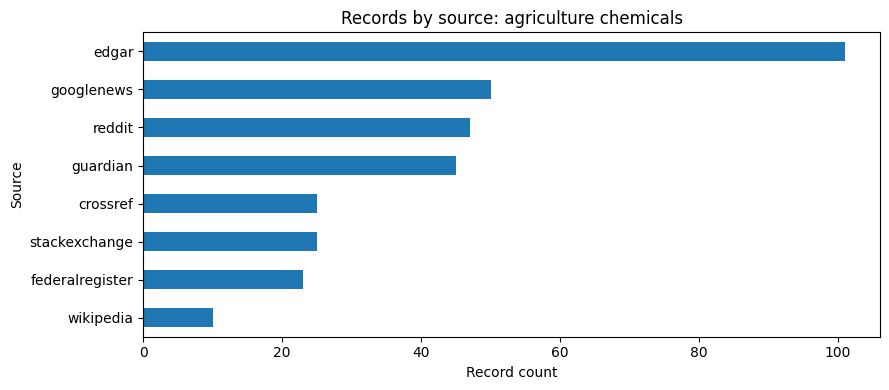

In [16]:
import matplotlib.pyplot as plt

source_counts = df["source"].value_counts().sort_values(ascending=True)
ax = source_counts.plot(kind="barh", figsize=(9, max(4, len(source_counts) * 0.35)))
ax.set_title(f"Records by source: {INDUSTRY}")
ax.set_xlabel("Record count")
ax.set_ylabel("Source")
plt.tight_layout()
plt.show()

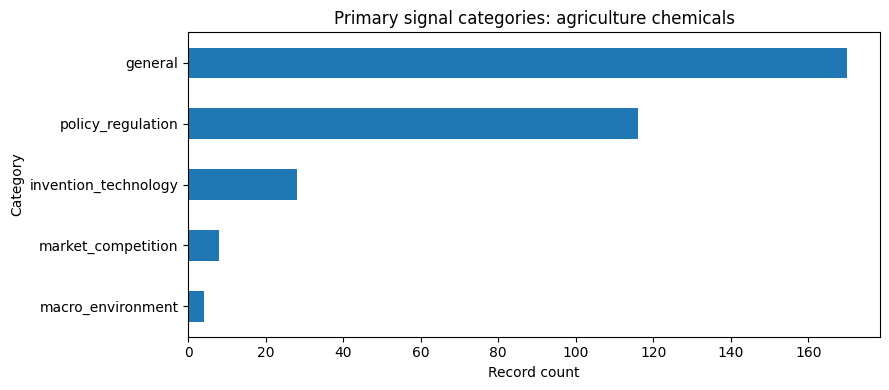

In [17]:
category_counts = df["primary_category"].value_counts().sort_values(ascending=True)
ax = category_counts.plot(kind="barh", figsize=(9, max(4, len(category_counts) * 0.45)))
ax.set_title(f"Primary signal categories: {INDUSTRY}")
ax.set_xlabel("Record count")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

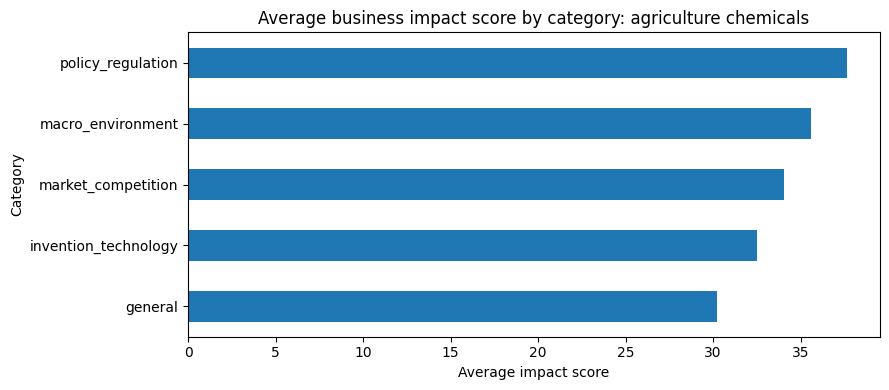

In [18]:
impact_by_category = (
    df.groupby("primary_category", dropna=False)["business_impact_score"]
    .mean()
    .sort_values(ascending=True)
)
ax = impact_by_category.plot(
    kind="barh", figsize=(9, max(4, len(impact_by_category) * 0.45))
)
ax.set_title(f"Average business impact score by category: {INDUSTRY}")
ax.set_xlabel("Average impact score")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

## 9. Visualize industry challenges

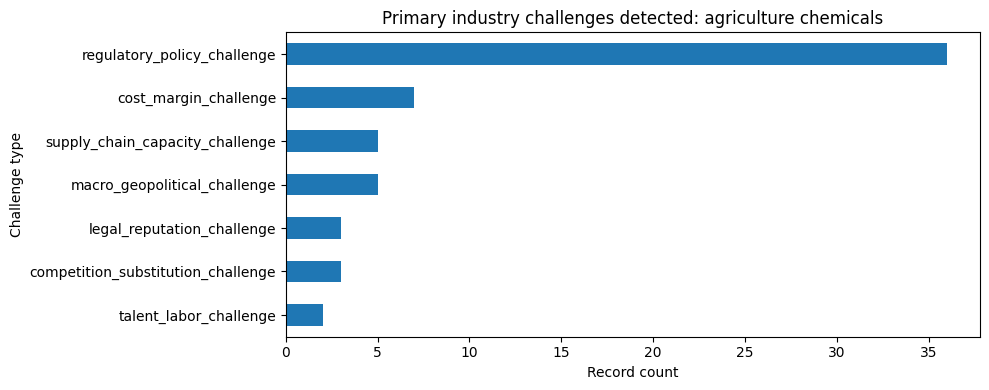

In [19]:
challenge_counts = (
    df.loc[df["is_challenge"], "primary_challenge"]
    .value_counts()
    .sort_values(ascending=True)
)

if challenge_counts.empty:
    print(
        "No explicit industry challenges detected. Tune CHALLENGE_TERMS or CHALLENGE_TAXONOMY if this seems wrong."
    )
else:
    ax = challenge_counts.plot(
        kind="barh", figsize=(10, max(4, len(challenge_counts) * 0.45))
    )
    ax.set_title(f"Primary industry challenges detected: {INDUSTRY}")
    ax.set_xlabel("Record count")
    ax.set_ylabel("Challenge type")
    plt.tight_layout()
    plt.show()

## 10. Build watchlists: policy, inventions, market/news, urgent risks, and challenges

In [20]:
def watchlist(
    category: str | None = None, direction: str | None = None, n: int = 15
) -> pd.DataFrame:
    tmp = top_df.copy()
    if category:
        tmp = tmp[tmp["signal_categories"].map(lambda cats: category in cats)]
    if direction:
        tmp = tmp[tmp["direction"] == direction]
    return tmp[score_cols].head(n)


def challenge_watchlist(challenge: str | None = None, n: int = 15) -> pd.DataFrame:
    tmp = top_df[top_df["is_challenge"]].copy()
    if challenge:
        tmp = tmp[tmp["challenge_categories"].map(lambda cats: challenge in cats)]
    tmp = tmp.sort_values(
        ["challenge_intensity_score", "business_impact_score", "urgency_score"],
        ascending=False,
    )
    return tmp[score_cols].head(n)


policy_watchlist = watchlist("policy_regulation", n=15)
invention_watchlist = watchlist("invention_technology", n=15)
market_watchlist = watchlist("market_competition", n=15)
risk_watchlist = watchlist(direction="risk", n=15)
opportunity_watchlist = watchlist(direction="opportunity", n=15)
industry_challenges_watchlist = challenge_watchlist(n=20)

print("Policy / regulation")
display(policy_watchlist)

print("Inventions / technology")
display(invention_watchlist)

print("Market / competition")
display(market_watchlist)

print("Urgent risks")
display(risk_watchlist)

print("Opportunities")
display(opportunity_watchlist)

print("Industry challenges / headwinds")
display(industry_challenges_watchlist)

Policy / regulation


,source,event_date,primary_category,direction,primary_challenge,business_impact_score,challenge_intensity_score,urgency_score,title,url,matched_industry_terms,impact_terms,matched_challenge_terms,challenge_severity_terms
0,reddit,2026-05-02 00:00:00+00:00,policy_regulation,mixed,competition_substitution_challenge,71.17,75.83,100.00,"Stock Market News — May 1, 2026 — Friday Eveni...",https://www.reddit.com/r/EverHint/comments/1t1...,"[regulation, biotech, robotics, ai]","[accelerating, acquisition, adoption, approval...","[challenge, pricing pressure, lawsuit, uncerta...","[critical, material, significant, major, accel..."
1,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,69.91,69.86,84.45,"[AI DAILY NEWS RUNDOWN] The GPT-5.5 Paradox, C...",https://www.reddit.com/r/u_enoumen/comments/1t...,"[supply chain, climate, ai]","[adoption, ban, contract, court, critical, def...","[ban, shortage]","[severe, critical, significant, ban, shortage,..."
2,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,65.25,71.61,91.34,America News Summary — 1 May 2026,https://www.reddit.com/r/u_minimarketuk/commen...,"[tariff, regulation, climate, ai]","[ban, competition, court, crisis, critical, de...","[competition, ban, volatility, uncertainty]","[severe, critical, crisis, significant, major,..."
3,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.75,61.61,87.00,The Daily Market Flux - Your Complete Market R...,https://www.reddit.com/r/MarketFluxHub/comment...,"[supply chain, tariff, robotics, ai]","[acquisition, adoption, approval, crisis, decl...",[uncertainty],"[crisis, significant, major, worsening, persis..."
4,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.41,73.61,91.11,What Trump Has Done - May 2026,https://www.reddit.com/r/WhatTrumpHasDone/comm...,"[fertilizer, tariff, epa, ai]","[approval, ban, contract, court, crisis, decli...","[lawsuit, enforcement, ban]","[crisis, material, major, unprecedented, enfor..."
5,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.25,67.61,88.67,Worked on these concepts: productivity paradox...,https://www.reddit.com/r/economicCollapse/comm...,"[tariff, regulation, climate, ai]","[accelerating, acquisition, competition, crisi...","[competition, uncertainty]","[critical, crisis, material, accelerating, str..."
6,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.25,67.61,88.67,Worked on these concepts: productivity paradox...,https://www.reddit.com/r/CapitalismVSocialism/...,"[tariff, regulation, climate, ai]","[accelerating, acquisition, competition, crisi...","[competition, uncertainty]","[critical, crisis, material, accelerating, str..."
7,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,61.75,55.53,85.11,"Stock Market News — April 30, 2026 — Evening U...",https://www.reddit.com/r/EverHint/comments/1t0...,"[tariff, regulation, ai]","[accelerating, acquisition, approval, challeng...","[challenge, headwind, constraint, supply disru...","[major, accelerating, structural]"
8,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,61.58,59.61,82.56,Wall Street Is About to Pay the Wrong People f...,https://www.reddit.com/r/Anduril/comments/1t0w...,"[supply chain, ai]","[acquisition, bankruptcy, bottleneck, contract...","[bottleneck, pricing pressure, substitution, e...","[major, structural, enforcement, bankruptcy]"
9,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,61.58,59.61,82.56,Wall Street Is About to Pay the Wrong People f...,https://www.reddit.com/r/u_Tuttle_Cap_Mgmt/com...,"[supply chain, ai]","[acquisition, bankruptcy, bottleneck, contract...","[bottleneck, pricing pressure, substitution, e...","[major, structural, enforcement, bankruptcy]"


Inventions / technology


,source,event_date,primary_category,direction,primary_challenge,business_impact_score,challenge_intensity_score,urgency_score,title,url,matched_industry_terms,impact_terms,matched_challenge_terms,challenge_severity_terms
0,reddit,2026-05-02 00:00:00+00:00,policy_regulation,mixed,competition_substitution_challenge,71.17,75.83,100.00,"Stock Market News — May 1, 2026 — Friday Eveni...",https://www.reddit.com/r/EverHint/comments/1t1...,"[regulation, biotech, robotics, ai]","[accelerating, acquisition, adoption, approval...","[challenge, pricing pressure, lawsuit, uncerta...","[critical, material, significant, major, accel..."
1,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,69.91,69.86,84.45,"[AI DAILY NEWS RUNDOWN] The GPT-5.5 Paradox, C...",https://www.reddit.com/r/u_enoumen/comments/1t...,"[supply chain, climate, ai]","[adoption, ban, contract, court, critical, def...","[ban, shortage]","[severe, critical, significant, ban, shortage,..."
2,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,65.25,71.61,91.34,America News Summary — 1 May 2026,https://www.reddit.com/r/u_minimarketuk/commen...,"[tariff, regulation, climate, ai]","[ban, competition, court, crisis, critical, de...","[competition, ban, volatility, uncertainty]","[severe, critical, crisis, significant, major,..."
3,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.75,61.61,87.00,The Daily Market Flux - Your Complete Market R...,https://www.reddit.com/r/MarketFluxHub/comment...,"[supply chain, tariff, robotics, ai]","[acquisition, adoption, approval, crisis, decl...",[uncertainty],"[crisis, significant, major, worsening, persis..."
4,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.41,73.61,91.11,What Trump Has Done - May 2026,https://www.reddit.com/r/WhatTrumpHasDone/comm...,"[fertilizer, tariff, epa, ai]","[approval, ban, contract, court, crisis, decli...","[lawsuit, enforcement, ban]","[crisis, material, major, unprecedented, enfor..."
5,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.25,67.61,88.67,Worked on these concepts: productivity paradox...,https://www.reddit.com/r/economicCollapse/comm...,"[tariff, regulation, climate, ai]","[accelerating, acquisition, competition, crisi...","[competition, uncertainty]","[critical, crisis, material, accelerating, str..."
6,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.25,67.61,88.67,Worked on these concepts: productivity paradox...,https://www.reddit.com/r/CapitalismVSocialism/...,"[tariff, regulation, climate, ai]","[accelerating, acquisition, competition, crisi...","[competition, uncertainty]","[critical, crisis, material, accelerating, str..."
7,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,61.75,55.53,85.11,"Stock Market News — April 30, 2026 — Evening U...",https://www.reddit.com/r/EverHint/comments/1t0...,"[tariff, regulation, ai]","[accelerating, acquisition, approval, challeng...","[challenge, headwind, constraint, supply disru...","[major, accelerating, structural]"
8,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,61.58,59.61,82.56,Wall Street Is About to Pay the Wrong People f...,https://www.reddit.com/r/Anduril/comments/1t0w...,"[supply chain, ai]","[acquisition, bankruptcy, bottleneck, contract...","[bottleneck, pricing pressure, substitution, e...","[major, structural, enforcement, bankruptcy]"
9,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,61.58,59.61,82.56,Wall Street Is About to Pay the Wrong People f...,https://www.reddit.com/r/u_Tuttle_Cap_Mgmt/com...,"[supply chain, ai]","[acquisition, bankruptcy, bottleneck, contract...","[bottleneck, pricing pressure, substitution, e...","[major, structural, enforcement, bankruptcy]"


Market / competition


...

,source,event_date,primary_category,direction,primary_challenge,business_impact_score,challenge_intensity_score,urgency_score,title,url,matched_industry_terms,impact_terms,matched_challenge_terms,challenge_severity_terms
36,reddit,2026-05-01 00:00:00+00:00,market_competition,risk,supply_chain_capacity_challenge,41.41,47.36,66.11,📉 Fertiliser Shortage Raises Food Alarm: Indus...,https://www.reddit.com/r/NoSpinMedia/comments/...,[fertilizer],"[critical, major, risk, shortage, warning, wor...",[shortage],"[critical, major, worsening, shortage]"
43,federalregister,2026-04-27 00:00:00+00:00,general,risk,none_detected,38.42,37.92,50.74,Endangered and Threatened Wildlife and Plants;...,https://www.federalregister.gov/documents/2026...,[],[critical],[],[critical]
44,guardian,2026-05-02 00:00:00+00:00,policy_regulation,risk,regulatory_policy_challenge,38.33,40.00,56.89,Organisers challenge Starmer’s threat to ban s...,https://www.theguardian.com/uk-news/2026/may/0...,[],"[ban, challenge]","[challenge, ban]",[ban]
58,guardian,2026-05-02 00:00:00+00:00,general,risk,none_detected,36.67,36.00,53.44,Solar booms in industrial US midwest as energy...,https://www.theguardian.com/us-news/2026/may/0...,[],[crisis],[],[crisis]
63,federalregister,2026-04-02 00:00:00+00:00,policy_regulation,risk,regulatory_policy_challenge,36.15,31.41,38.16,Finding of Failure To Attain the 2006 24-Hour ...,https://www.federalregister.gov/documents/2026...,[epa],"[court, epa, fine]",[],[]
66,reddit,2026-04-29 00:00:00+00:00,policy_regulation,risk,regulatory_policy_challenge,36.08,38.84,60.25,⚖️ Maine Judge Blocks Augusta School Board Spe...,https://www.reddit.com/r/NewEnglandContext/com...,[],"[court, disruption, enforcement, lawsuit, policy]","[lawsuit, enforcement]","[enforcement, lawsuit]"
80,reddit,2026-04-30 00:00:00+00:00,policy_regulation,risk,regulatory_policy_challenge,35.33,35.06,58.12,[Scorch Directive AU] Balance of Vengeance III...,https://www.reddit.com/r/NatureofPredators/com...,[],"[breach, drop, fine, major, recall]",[],"[major, recall]"
84,federalregister,2026-02-18 00:00:00+00:00,policy_regulation,risk,regulatory_policy_challenge,35.22,36.05,30.66,Rescission of the Greenhouse Gas Endangerment ...,https://www.federalregister.gov/documents/2026...,"[epa, climate]","[epa, major, material, rule]",[],"[material, major]"
87,federalregister,2026-03-05 00:00:00+00:00,policy_regulation,risk,regulatory_policy_challenge,35.07,29.67,29.36,Clean Water Act Hazardous Substance Facility R...,https://www.federalregister.gov/documents/2026...,"[epa, climate]","[delay, epa, policy, rule]",[],[]
121,googlenews,2026-02-22 00:00:00+00:00,policy_regulation,risk,regulatory_policy_challenge,34.68,29.62,24.78,Trump tariffs: The uncertainties facing busine...,https://news.google.com/rss/articles/CBMiWkFVX...,"[agriculture, tariff]","[policy, tariff]",[],[]


Opportunities


,source,event_date,primary_category,direction,primary_challenge,business_impact_score,challenge_intensity_score,urgency_score,title,url,matched_industry_terms,impact_terms,matched_challenge_terms,challenge_severity_terms
39,crossref,2026-03-03 00:00:00+00:00,invention_technology,opportunity,none_detected,39.94,33.57,27.23,AI Powers Agriculture 4.0,https://doi.org/10.1080/08956308.2026.2614268,"[agriculture, ai]","[breakthrough, patent]",[],[]
46,crossref,2026-05-01 00:00:00+00:00,invention_technology,opportunity,none_detected,37.55,32.66,51.00,A dielectric spectrometer based on the quasi-s...,https://doi.org/10.1016/j.jafr.2026.102891,[agriculture],"[breakthrough, patent]",[],[]
47,crossref,2026-05-01 00:00:00+00:00,invention_technology,opportunity,none_detected,37.55,32.66,51.00,Reactive acrylate-functional POSS-modified wat...,https://doi.org/10.1016/j.porgcoat.2026.110040,[agriculture],"[breakthrough, patent]",[],[]
50,googlenews,2026-03-13 00:00:00+00:00,policy_regulation,opportunity,none_detected,37.20,31.81,30.24,Synthetic Crop Protection Chemicals Market Tre...,https://news.google.com/rss/articles/CBMijAFBV...,"[agriculture, crop protection]","[growth, policy]",[],[]
51,reddit,2026-05-02 00:00:00+00:00,policy_regulation,opportunity,none_detected,37.17,29.58,54.67,Paid Social Strategist,https://www.reddit.com/r/ppcjobs/comments/1t1d...,[ai],"[adoption, demand, growth, incentive, innovati...",[],[]
73,googlenews,2026-03-03 00:00:00+00:00,policy_regulation,opportunity,none_detected,35.81,30.60,27.23,"Europe Crop Protection Chemicals Market Size, ...",https://news.google.com/rss/articles/CBMiiAFBV...,"[agriculture, crop protection]","[growth, policy]",[],[]
76,crossref,2026-03-27 00:00:00+00:00,invention_technology,opportunity,none_detected,35.55,30.46,35.07,Agriculture Excellence: Harnessing Precision T...,https://doi.org/10.64643/ijirtv12i11-195541-459,[agriculture],"[breakthrough, patent]",[],[]
77,guardian,2026-05-01 00:00:00+00:00,general,opportunity,none_detected,35.41,31.78,50.23,European countries still expect to lose money ...,https://www.theguardian.com/football/2026/may/...,[],[increase],[],[]
78,guardian,2026-05-01 00:00:00+00:00,market_competition,opportunity,none_detected,35.41,31.78,50.23,Demand for guns has surged in the wake of the ...,https://www.theguardian.com/australia-news/202...,[],[demand],[],[]
81,federalregister,2026-04-01 00:00:00+00:00,policy_regulation,opportunity,none_detected,35.30,31.26,36.99,Renewable Fuel Standard (RFS) Program: Standar...,https://www.federalregister.gov/documents/2026...,[epa],"[epa, standard]",[],[]


Industry challenges / headwinds


,source,event_date,primary_category,direction,primary_challenge,business_impact_score,challenge_intensity_score,urgency_score,title,url,matched_industry_terms,impact_terms,matched_challenge_terms,challenge_severity_terms
0,reddit,2026-05-02 00:00:00+00:00,policy_regulation,mixed,competition_substitution_challenge,71.17,75.83,100.00,"Stock Market News — May 1, 2026 — Friday Eveni...",https://www.reddit.com/r/EverHint/comments/1t1...,"[regulation, biotech, robotics, ai]","[accelerating, acquisition, adoption, approval...","[challenge, pricing pressure, lawsuit, uncerta...","[critical, material, significant, major, accel..."
4,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.41,73.61,91.11,What Trump Has Done - May 2026,https://www.reddit.com/r/WhatTrumpHasDone/comm...,"[fertilizer, tariff, epa, ai]","[approval, ban, contract, court, crisis, decli...","[lawsuit, enforcement, ban]","[crisis, material, major, unprecedented, enfor..."
2,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,65.25,71.61,91.34,America News Summary — 1 May 2026,https://www.reddit.com/r/u_minimarketuk/commen...,"[tariff, regulation, climate, ai]","[ban, competition, court, crisis, critical, de...","[competition, ban, volatility, uncertainty]","[severe, critical, crisis, significant, major,..."
1,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,69.91,69.86,84.45,"[AI DAILY NEWS RUNDOWN] The GPT-5.5 Paradox, C...",https://www.reddit.com/r/u_enoumen/comments/1t...,"[supply chain, climate, ai]","[adoption, ban, contract, court, critical, def...","[ban, shortage]","[severe, critical, significant, ban, shortage,..."
5,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.25,67.61,88.67,Worked on these concepts: productivity paradox...,https://www.reddit.com/r/economicCollapse/comm...,"[tariff, regulation, climate, ai]","[accelerating, acquisition, competition, crisi...","[competition, uncertainty]","[critical, crisis, material, accelerating, str..."
6,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.25,67.61,88.67,Worked on these concepts: productivity paradox...,https://www.reddit.com/r/CapitalismVSocialism/...,"[tariff, regulation, climate, ai]","[accelerating, acquisition, competition, crisi...","[competition, uncertainty]","[critical, crisis, material, accelerating, str..."
3,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,64.75,61.61,87.00,The Daily Market Flux - Your Complete Market R...,https://www.reddit.com/r/MarketFluxHub/comment...,"[supply chain, tariff, robotics, ai]","[acquisition, adoption, approval, crisis, decl...",[uncertainty],"[crisis, significant, major, worsening, persis..."
8,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,61.58,59.61,82.56,Wall Street Is About to Pay the Wrong People f...,https://www.reddit.com/r/Anduril/comments/1t0w...,"[supply chain, ai]","[acquisition, bankruptcy, bottleneck, contract...","[bottleneck, pricing pressure, substitution, e...","[major, structural, enforcement, bankruptcy]"
9,reddit,2026-05-01 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,61.58,59.61,82.56,Wall Street Is About to Pay the Wrong People f...,https://www.reddit.com/r/u_Tuttle_Cap_Mgmt/com...,"[supply chain, ai]","[acquisition, bankruptcy, bottleneck, contract...","[bottleneck, pricing pressure, substitution, e...","[major, structural, enforcement, bankruptcy]"
11,reddit,2026-04-30 00:00:00+00:00,policy_regulation,mixed,regulatory_policy_challenge,58.49,59.31,82.57,The Network I: The People Who Built Anduril an...,https://www.reddit.com/r/u_HealthyMindHappyLif...,"[supply chain, robotics, ai]","[accelerating, challenge, contract, enforcemen...","[challenge, lawsuit, enforcement]","[material, significant, accelerating, enforcem..."


## 11. Export CSVs and a Markdown intelligence report

In [21]:
EXPORT_COLUMNS = [
    "source",
    "event_date",
    "published_date",
    "fetched_at",
    "record_type",
    "primary_category",
    "signal_categories",
    "direction",
    "primary_challenge",
    "challenge_categories",
    "is_challenge",
    "business_impact_score",
    "challenge_intensity_score",
    "urgency_score",
    "relevance_score",
    "freshness_score",
    "signal_strength_score",
    "challenge_strength_score",
    "source_weight",
    "title",
    "abstract",
    "url",
    "matched_industry_terms",
    "impact_terms",
    "matched_challenge_terms",
    "challenge_severity_terms",
    "cluster",
    "cluster_label",
]

export_df = cluster_df.copy()
for col in EXPORT_COLUMNS:
    if col not in export_df.columns:
        export_df[col] = None

# Make list columns readable in CSV.
for col in [
    "signal_categories",
    "challenge_categories",
    "matched_industry_terms",
    "impact_terms",
    "matched_challenge_terms",
    "challenge_severity_terms",
]:
    export_df[col] = export_df[col].map(
        lambda x: "; ".join(x) if isinstance(x, list) else x
    )

export_df[EXPORT_COLUMNS].to_csv(CLEAN_CSV, index=False)
top_df[score_cols].head(100).to_csv(TOP_SIGNALS_CSV, index=False)
industry_challenges_watchlist.to_csv(
    OUT_DIR / "top_industry_challenges.csv", index=False
)

print(f"Wrote {CLEAN_CSV}")
print(f"Wrote {TOP_SIGNALS_CSV}")
print(f"Wrote {OUT_DIR / 'top_industry_challenges.csv'}")
print(f"Wrote {API_COVERAGE_CSV}")

Wrote data/industry_signal_intelligence/clean_industry_signals.csv
Wrote data/industry_signal_intelligence/top_business_impact_signals.csv
Wrote data/industry_signal_intelligence/top_industry_challenges.csv
Wrote data/industry_signal_intelligence/api_fetcher_coverage.csv


In [22]:
def md_link(title: str, url: str) -> str:
    title = compact_spaces(title) or "Untitled"
    if url:
        return f"[{title}]({url})"
    return title


def report_section(name: str, data: pd.DataFrame, n: int = 10) -> str:
    lines = [f"## {name}", ""]
    if data.empty:
        return "\n".join(lines + ["No records found.", ""])
    for _, row in data.head(n).iterrows():
        event_date = row.get("event_date")
        if pd.notna(event_date):
            event_date = pd.to_datetime(event_date).date().isoformat()
        else:
            event_date = "unknown date"
        title = str(row.get("title", "Untitled"))
        url = str(row.get("url", ""))
        challenge = row.get("primary_challenge", "none_detected")
        challenge_text = (
            f" | challenge: {challenge}"
            if challenge and challenge != "none_detected"
            else ""
        )
        lines.append(
            f"- **{row.get('business_impact_score', 0)}** | "
            f"challenge **{row.get('challenge_intensity_score', 0)}** | "
            f"{row.get('source', 'unknown')} | {event_date} | "
            f"{row.get('primary_category', 'general')} | {row.get('direction', 'neutral')}"
            f"{challenge_text} — {md_link(title, url)}"
        )
        impact_terms = row.get("impact_terms", [])
        if isinstance(impact_terms, list) and impact_terms:
            lines.append(f"  - Impact terms: {', '.join(impact_terms[:8])}")
        challenge_terms = row.get("matched_challenge_terms", [])
        if isinstance(challenge_terms, list) and challenge_terms:
            lines.append(f"  - Challenge terms: {', '.join(challenge_terms[:8])}")
    lines.append("")
    return "\n".join(lines)


challenge_summary = (
    df.loc[df["is_challenge"]]
    .groupby("primary_challenge")
    .agg(
        records=("title", "count"),
        avg_business_impact=("business_impact_score", "mean"),
        avg_challenge_intensity=("challenge_intensity_score", "mean"),
        avg_urgency=("urgency_score", "mean"),
    )
    .sort_values(["avg_challenge_intensity", "records"], ascending=False)
    .round(2)
)

challenge_summary_lines = ["## Challenge summary", ""]
if challenge_summary.empty:
    challenge_summary_lines += ["No explicit industry challenges detected.", ""]
else:
    for challenge, row in challenge_summary.iterrows():
        challenge_summary_lines.append(
            f"- **{challenge}**: {int(row['records'])} records; "
            f"avg challenge intensity {row['avg_challenge_intensity']}; "
            f"avg business impact {row['avg_business_impact']}; "
            f"avg urgency {row['avg_urgency']}"
        )
    challenge_summary_lines.append("")

api_coverage_lines = ["## API / fetcher coverage", ""]
try:
    coverage_for_report = (
        api_fetcher_coverage.groupby("source")
        .agg(
            specs=("idx", "count"),
            built=("status", lambda s: int((s == "built").sum())),
            skipped=("status", lambda s: int((s == "skipped").sum())),
            reason=("reason", lambda s: next((x for x in s if x), "")),
        )
        .reset_index()
        .sort_values(["built", "source"], ascending=[False, True])
    )
    for _, row in coverage_for_report.iterrows():
        reason = f" — {row['reason']}" if row.get("reason") else ""
        api_coverage_lines.append(
            f"- **{row['source']}**: built {int(row['built'])}/{int(row['specs'])} spec(s); "
            f"skipped {int(row['skipped'])}{reason}"
        )
    api_coverage_lines.append("")
except NameError:
    api_coverage_lines.append("Coverage table was not available in this run.")
    api_coverage_lines.append("")


report_parts = [
    f"# Industry Signal Report: {INDUSTRY}",
    "",
    f"Generated: {datetime.now().isoformat(timespec='seconds')}",
    "",
    f"Industry description: {INDUSTRY_DESCRIPTION}",
    "",
    f"Window: {START_DATE} to {END_DATE}",
    "",
    f"Records analyzed after dedupe: {len(df):,}",
    "",
    "\n".join(api_coverage_lines),
    "## Executive reading guide",
    "",
    "- **Business impact score** combines relevance, freshness, signal strength, and source trust.",
    "- **Challenge intensity score** focuses on strategic headwinds such as regulatory burden, cost pressure, adoption barriers, competition, supply-chain constraints, labor shortages, technical execution risk, legal/reputation issues, and macro/geopolitical pressure.",
    "- **Risk** records contain terms like ban, fine, lawsuit, shortage, disruption, enforcement, or severe challenge terms.",
    "- **Opportunity** records contain terms like funding, approval, growth, partnership, contract, patent, or incentive.",
    "- Treat this as a triage system, not a final investment/legal decision engine.",
    "",
    "\n".join(challenge_summary_lines),
    report_section("Top signals", top_df, 20),
    report_section(
        "Industry challenges and headwinds", industry_challenges_watchlist, 20
    ),
    report_section("Policy and regulation watchlist", policy_watchlist, 15),
    report_section("Inventions and technology watchlist", invention_watchlist, 15),
    report_section("Market and competition watchlist", market_watchlist, 15),
    report_section("Risk watchlist", risk_watchlist, 15),
    report_section("Opportunity watchlist", opportunity_watchlist, 15),
    "## Suggested next actions",
    "",
    "1. Review the challenge summary first to understand the biggest strategic headwinds.",
    "2. Review top policy and legal signals manually before acting.",
    "3. Add high-value industry websites to `WATCH_SITES`.",
    "4. Tune `INDUSTRY_TERMS`, `ADJACENT_TERMS`, `CHALLENGE_TERMS`, `SIGNAL_TAXONOMY`, and `CHALLENGE_TAXONOMY` after inspecting false positives.",
    "5. Store daily runs in a warehouse or object store for trend analysis over time.",
]

REPORT_MD.write_text("\n".join(report_parts), encoding="utf-8")
print(f"Wrote {REPORT_MD}")

Wrote data/industry_signal_intelligence/industry_signal_report.md


## 12. Optional: turn the notebook into a scheduled job

In [23]:
# Option A: execute the notebook daily with papermill.
# %pip install papermill
# !papermill examples/industry_signal_intelligence_text_ingest.ipynb data/runs/industry_signal_$(date +%F).ipynb

# Option B: convert notebook logic into a script and run with cron/GitHub Actions/Airflow.
# The current repo already includes examples for CSV/parquet export and Airflow usage.

# Recommended production storage layout:
# data/industry_signal_intelligence/raw/dt=YYYY-MM-DD/*.jsonl
# data/industry_signal_intelligence/clean/dt=YYYY-MM-DD/*.parquet
# data/industry_signal_intelligence/reports/dt=YYYY-MM-DD/report.md